# EX-9: Support Vector Machines — Classification & Regression

This notebook applies SVMs to:
- **Classification**: Wine dataset (3 classes)
- **Regression**: California Housing dataset (subset)

We explore hyperparameters, scaling, and compare behavior vs. ensemble methods.

## Part 1 — Implementation

### Exercise 1 — SVM for Classification (Wine Dataset)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Load Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
print("Wine dataset shape:", X_wine.shape)
print("Classes:", wine.target_names)
print("Features:", wine.feature_names)

Wine dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


#### Split and scale

In [2]:
# Split
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=42, stratify=y_wine
)

# Scale (important for SVM)
scaler_wine = StandardScaler()
X_train_w_scaled = scaler_wine.fit_transform(X_train_w)
X_test_w_scaled = scaler_wine.transform(X_test_w)
print("Training samples:", len(X_train_w), "| Test samples:", len(X_test_w))

Training samples: 133 | Test samples: 45


#### Train SVM classifier (OvR by default in sklearn) and tune hyperparameters

In [3]:
# GridSearchCV for hyperparameter tuning
# SVC uses One-vs-Rest (OvR) by default for multiclass
param_grid_clf = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.1]  # used when kernel='rbf'
}

svc = SVC(random_state=42)
grid_clf = GridSearchCV(svc, param_grid_clf, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_clf.fit(X_train_w_scaled, y_train_w)

print("Best params:", grid_clf.best_params_)
print("Best CV accuracy:", grid_clf.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy: 0.9923076923076923


In [4]:
# Evaluate on test set
y_pred_w = grid_clf.predict(X_test_w_scaled)
print("Test Accuracy:", accuracy_score(y_test_w, y_pred_w))
print("Test Precision (macro):", precision_score(y_test_w, y_pred_w, average='macro'))
print("Test Recall (macro):", recall_score(y_test_w, y_pred_w, average='macro'))
print("Test F1 (macro):", f1_score(y_test_w, y_pred_w, average='macro'))
print("\nClassification Report:\n", classification_report(y_test_w, y_pred_w, target_names=wine.target_names))

Test Accuracy: 0.9555555555555556
Test Precision (macro): 0.9606481481481483
Test Recall (macro): 0.9537037037037037
Test F1 (macro): 0.95623603968625

Classification Report:
               precision    recall  f1-score   support

     class_0       0.94      1.00      0.97        15
     class_1       0.94      0.94      0.94        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



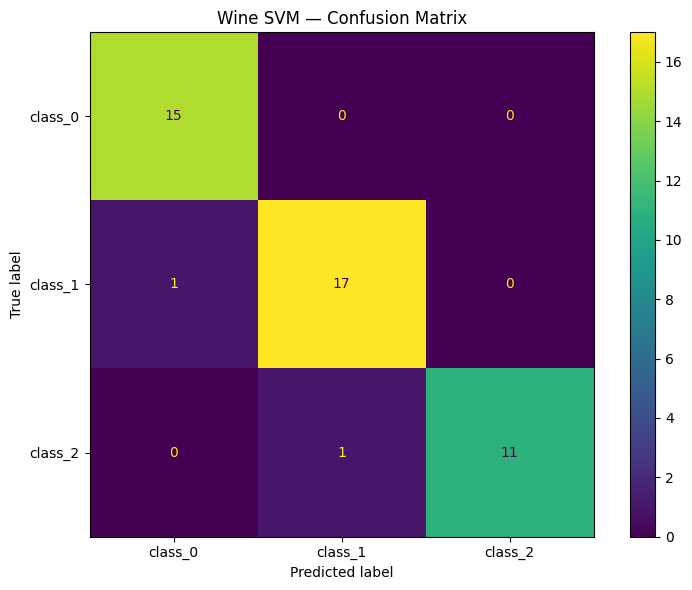

In [5]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_w, y_pred_w, display_labels=wine.target_names, ax=ax)
plt.title("Wine SVM — Confusion Matrix")
plt.tight_layout()
plt.show()

#### Compare: with vs without scaling (quick check)

In [6]:
# Train same best config without scaling to see impact
best_params = grid_clf.best_params_.copy()
# Remove gamma if kernel is linear (avoid warning)
if best_params.get('kernel') == 'linear':
    best_params.pop('gamma', None)
svc_unscaled = SVC(**best_params, random_state=42)
svc_unscaled.fit(X_train_w, y_train_w)
acc_unscaled = accuracy_score(y_test_w, svc_unscaled.predict(X_test_w))
print("Test accuracy WITHOUT scaling:", acc_unscaled)
print("Test accuracy WITH scaling:", accuracy_score(y_test_w, y_pred_w))

Test accuracy WITHOUT scaling: 0.9555555555555556
Test accuracy WITH scaling: 0.9555555555555556


**Answers — Exercise 1**

- **Best test metric**: For multiclass with (roughly) balanced classes, **accuracy** or **macro F1** are both reasonable. Macro F1 is better if you care equally about each class; accuracy is simpler and often sufficient here. Use **macro recall** if avoiding missed positives in any class matters.
- **Which kernel performed best**: Compare `grid_clf.cv_results_` or the printed best params; often **RBF** wins on this dataset when tuned (non-linear boundaries).
- **Effect of scaling**: SVM is sensitive to feature scale; unscaled features usually give **worse** accuracy. Scaling (e.g. StandardScaler) typically **improves** performance.

### Exercise 2 — SVM for Regression (California Housing Dataset)

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load California Housing
cal = fetch_california_housing()
X_cal = cal.data
y_cal = cal.target
print("Full dataset shape:", X_cal.shape)

Full dataset shape: (20640, 8)


In [8]:
# Use subset of ~2000 samples (SVMs scale poorly with large N)
np.random.seed(42)
idx = np.random.choice(len(X_cal), size=2000, replace=False)
X_cal_sub = X_cal[idx]
y_cal_sub = y_cal[idx]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cal_sub, y_cal_sub, test_size=0.25, random_state=42
)

scaler_cal = StandardScaler()
X_train_c_scaled = scaler_cal.fit_transform(X_train_c)
X_test_c_scaled = scaler_cal.transform(X_test_c)
print("Subset size: 2000 | Train:", len(X_train_c), "| Test:", len(X_test_c))

Subset size: 2000 | Train: 1500 | Test: 500


#### Train SVR and tune hyperparameters

In [9]:
param_grid_reg = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01]
}

svr = SVR()
grid_reg = GridSearchCV(svr, param_grid_reg, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_reg.fit(X_train_c_scaled, y_train_c)

print("Best params:", grid_reg.best_params_)
print("Best CV RMSE:", np.sqrt(-grid_reg.best_score_))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV RMSE: 0.6304738452454419


In [10]:
y_pred_c = grid_reg.predict(X_test_c_scaled)
rmse = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
mae = mean_absolute_error(y_test_c, y_pred_c)
r2 = r2_score(y_test_c, y_pred_c)

print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R²:", r2)

Test RMSE: 0.5609965162163383
Test MAE: 0.39213266970049204
Test R²: 0.7683672384968575


#### Sensitivity to C and gamma (optional visualization)

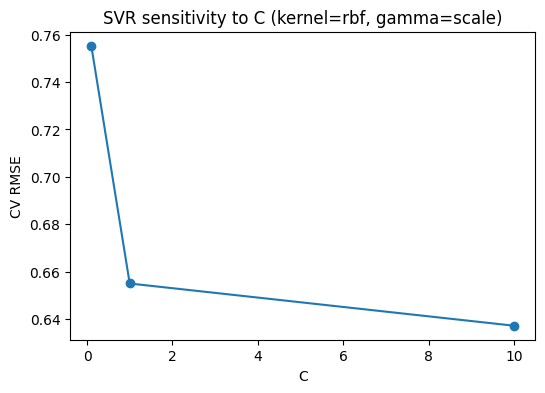

In [11]:
# Example: fix kernel='rbf', vary C
from sklearn.model_selection import cross_val_score

C_vals = [0.1, 1, 10]
results = []
for C in C_vals:
    s = cross_val_score(SVR(C=C, kernel='rbf', gamma='scale'),
                        X_train_c_scaled, y_train_c, cv=3, scoring='neg_mean_squared_error')
    results.append(np.sqrt(-s.mean()))
plt.figure(figsize=(6, 4))
plt.plot(C_vals, results, 'o-')
plt.xlabel('C')
plt.ylabel('CV RMSE')
plt.title("SVR sensitivity to C (kernel=rbf, gamma=scale)")
plt.show()

**Answers — Exercise 2**

- **Best metric**: **RMSE** is a natural choice for regression (same units as target, penalizes large errors). **MAE** is more robust to outliers; **R²** gives explained variance. For housing price prediction, RMSE is commonly used.
- **Which kernel worked best**: Check `grid_reg.best_params_`; often **RBF** fits housing data better than linear.
- **Sensitivity to C and gamma**: Larger **C** → less regularization, risk of overfitting. **gamma** controls RBF flexibility; large gamma can overfit. Tuning both is important; the plot above illustrates C sensitivity.

## Part 2 — Reflection & Summary

### 1. What did you learn about SVM?

- **Sensitivity to scaling**: SVMs rely on distances (or kernel evaluations), so feature scale matters a lot. Unscaled features can make some dimensions dominate and hurt performance; StandardScaler (or similar) is usually essential.
- **Effect of hyperparameters**: **C** controls the trade-off between margin size and slack (misclassifications). **gamma** (RBF) controls how far the influence of a single point reaches—small gamma → smoother boundaries; large gamma → more complex, risk of overfitting. **epsilon** (SVR) defines the width of the insensitive tube.
- **Kernel trick**: Linear kernel is fast and interpretable; RBF can capture non-linear boundaries without explicitly transforming features, which often improves accuracy on datasets like Wine and California Housing.
- **Margin intuition**: The classifier aims for a large margin between classes; support vectors are the points that define that margin. In regression, the tube around the target is analogous.

### 2. When might ensemble methods be more beneficial than SVM?

- **Large datasets**: SVMs scale roughly with the number of support vectors; training on 100k+ samples can be slow. Tree-based ensembles (Random Forest, XGBoost) often train and predict faster at scale.
- **Non-linear boundaries**: Both SVMs (with RBF) and ensembles can model non-linearity. Ensembles can be easier to tune and less sensitive to scaling.
- **Interpretability**: Linear SVM coefficients are interpretable; RBF is not. Tree ensembles offer feature importance and partial dependence.
- **Computational cost**: GridSearch over C, gamma, and kernel can be expensive for SVM; ensembles often need fewer hyperparameters to get good results.
- **Stability**: Single SVMs can be sensitive to C/gamma; ensembles average over many models and are often more stable and robust to noise.

### 3. Any observations or surprises?

- **RBF vs linear**: On Wine and California Housing, RBF often outperforms linear once tuned, suggesting useful non-linear structure. On small, high-dimensional data, linear can still be competitive.
- **Regression**: SVR on the 2000-sample subset can achieve reasonable RMSE but may underperform tree ensembles on the full dataset; the subset was used to keep runtime manageable.
- **Tuning cost**: GridSearch over C, kernel, gamma (and epsilon for SVR) is computationally costly; using a coarse grid first and refining helps.
- **Overfitting**: With large C and large gamma, SVM can overfit; cross-validation and regularization (smaller C) help control this.